In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import utils

## Phantom Data

In [23]:
data_dir = "./data/stripped/"
filepath = data_dir + "13.0.mat"

BFData, ReconParams = utils.extract_mat_file(filepath)

Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64


In [24]:
def plot_beamformed_image(BFData, ReconParams, mode='BMode', figsize=(10, 8),
                          cmap='bone', show_colorbar=True,
                          IMG_max=None, IMG_min=None, db_range=45, full_db_range=False):
    mode = mode.lower()
    if mode == 'am':
        iq_data = BFData.get('IQ_xAM')
        title = 'Log‑compressed IQ_xAM'
    elif mode == 'bmode':
        iq_data = BFData.get('IQ_xBMode')
        title = 'Log‑compressed IQ_xBMode'
    else:
        raise ValueError("mode must be 'AM' or 'BMode'")

    if iq_data is None:
        raise KeyError(f"Data for mode {mode} not found in BFData")

    envelope = np.abs(iq_data)
    envelope = envelope.T
    
    #log-compression
    if IMG_max is None:
        IMG_max = np.max(envelope)
    if IMG_min is None:
        min_db = -db_range
    else:
        min_db = 20 * np.log10(IMG_min / IMG_max)
    
    if full_db_range==True:
        min_db = 20 * np.log10(np.min(envelope) / np.max(envelope))

    log_env = 20 * np.log10(envelope / IMG_max)

    img_compressed = np.clip(log_env, min_db, 0)

    # Physical axes (meters -> mm)
    grid_origin = ReconParams['GridOrigin']
    grid_scale_x = ReconParams['GridScaleX'] 
    grid_scale_z = ReconParams['GridScaleZ']

    n_depth, n_lateral = iq_data.shape
    lateral_mm = (grid_origin[0] + np.arange(n_lateral) * grid_scale_x) * 1000
    depth_mm  = (grid_origin[2] + np.arange(n_depth)  * grid_scale_z) * 1000
    depth_mm = np.flip(depth_mm)
    
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(img_compressed,
                   extent=[lateral_mm[0], lateral_mm[-1], depth_mm[0], depth_mm[-1]],
                   aspect='equal',
                   cmap=cmap,
                   vmin=min_db, vmax=0)          # set dB range explicitly
    ax.set_ylabel('Depth (mm)')
    ax.set_xlabel('Lateral Position (mm)')
    ax.set_title(title)

    if show_colorbar:
        cbar = plt.colorbar(im, ax=ax, label='Amplitude (dB)')   # now labels dB correctly

    plt.tight_layout()
    return img_compressed, envelope, lateral_mm, depth_mm

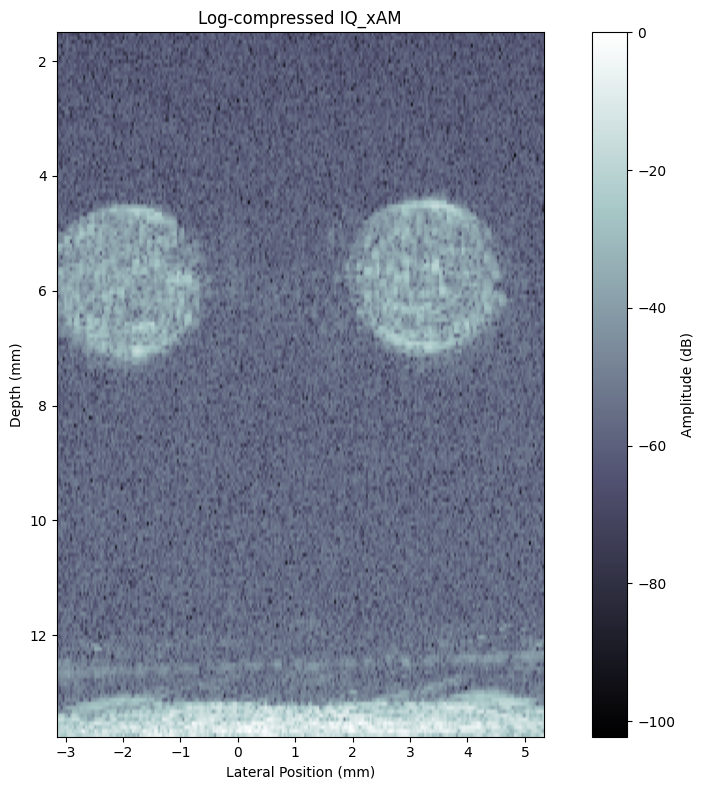

In [25]:
full_db_range = True

img_log, envelope, lateral_mm, depth_mm = plot_beamformed_image(BFData, ReconParams, mode='AM', full_db_range=full_db_range)

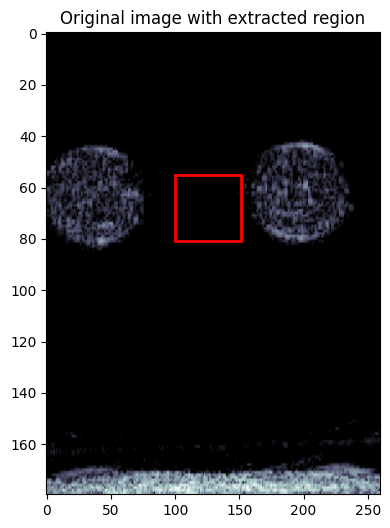

In [29]:
## Find the mean intensity of a background region by defining index ranges (idx_start, idx_end)
depth_range =      (55,80)
lateral_range =    (100,150)

sub = utils.extract_subimage(envelope, depth_range=depth_range, lateral_range=lateral_range)

IMG_min =  np.mean(sub)        #TODO

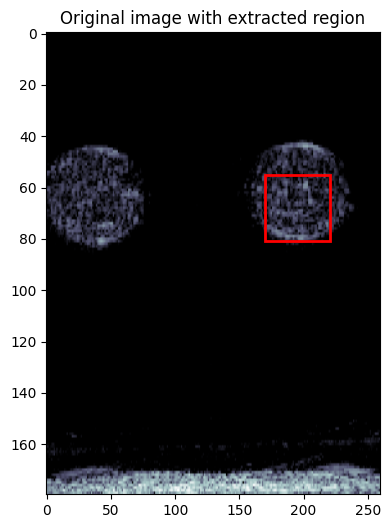

In [32]:
## Find the max intensity of a well by defining index ranges (idx_start, idx_end)
lateral_range =    (170,220)

sub = utils.extract_subimage(envelope, depth_range=depth_range, lateral_range=lateral_range)

IMG_max = np.max(sub)          #TODO

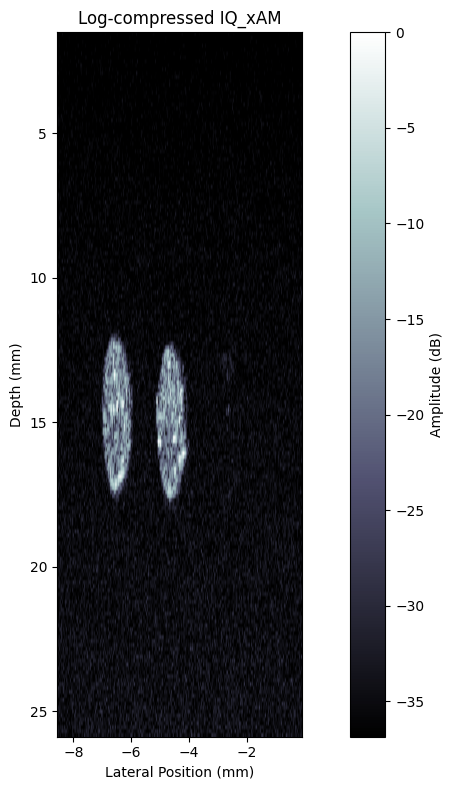

In [21]:
## Plot reconstruction with CNR based dynamic range

img_log, envelope, lateral_mm, depth_mm = plot_beamformed_image(BFData, ReconParams, mode='AM', IMG_min=IMG_min, IMG_max=IMG_max)

In [22]:
# Compute CNR in dB
cnr = 20 * np.log10(IMG_max / IMG_min)

print('CNR =', cnr)

CNR = 36.850082


In [ ]:
## Repeat CNR computation for all Stripped GV images and store values
stripped_gv_cnr_list = []


In [33]:
import os, glob

# Region indices for the Stripped series — edit as needed
stripped_regions = dict(
    bg_depth_range     = (55, 70),
    bg_lateral_range   = (100, 150),
    well_depth_range   = (55, 70),
    well_lateral_range = (170, 220),
)

stripped_dir = "./data/stripped/"
stripped_files = sorted(
    glob.glob(os.path.join(stripped_dir, "*.mat")),
    key=lambda p: float(os.path.splitext(os.path.basename(p))[0]),
)

stripped_gv_cnr_list = []
for fp in stripped_files:
    voltage = float(os.path.splitext(os.path.basename(fp))[0])
    BFData, _ = utils.extract_mat_file(fp)
    envelope = np.abs(BFData['IQ_xAM']).T

    bg   = utils.extract_subimage(envelope,
                                  depth_range   = stripped_regions['bg_depth_range'],
                                  lateral_range = stripped_regions['bg_lateral_range'],
                                  plot=False)
    well = utils.extract_subimage(envelope,
                                  depth_range   = stripped_regions['well_depth_range'],
                                  lateral_range = stripped_regions['well_lateral_range'],
                                  plot=False)
    img_min = float(np.mean(bg))
    img_max = float(np.max(well))
    cnr = 20.0 * np.log10(img_max / img_min)

    stripped_gv_cnr_list.append((voltage, cnr))
    print(f"V = {voltage:>5} V  ->  CNR = {cnr:6.2f} dB")


Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64
V =   1.6 V  ->  CNR =  10.25 dB
Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64
V =   3.0 V  ->  CNR =  22.86 dB
Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64
V =   4.4 V  ->  CNR =  35.31 dB
Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64
V =   5.9 V  ->  CNR =  40.65 dB
Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64
V =   7.0 V  ->  CNR =  40.65 dB
Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64
V =   8.7 V  ->  CNR =  38.46 dB
Loaded IQ_xAM with shape: (260, 180), dtype: complex64
Loaded IQ_xBMode with shape: (260, 180), dtype: complex64
V =  10.1 V

In [24]:
## Repeat CNR computation for all Wild Type GV images and store values
wild_type_gv_cnr_list = []


In [34]:
import os, glob

# Region indices for the Wild Type series — values set during interactive tuning
wild_type_regions = dict(
    bg_depth_range     = (90, 110),
    bg_lateral_range   = (20, 80),
    well_depth_range   = (90, 110),
    well_lateral_range = (220, 260),
)

wild_type_dir = "./data/wt/"
wild_type_files = sorted(
    glob.glob(os.path.join(wild_type_dir, "*.mat")),
    key=lambda p: float(os.path.splitext(os.path.basename(p))[0]),
)

wild_type_gv_cnr_list = []
for fp in wild_type_files:
    voltage = float(os.path.splitext(os.path.basename(fp))[0])
    BFData, _ = utils.extract_mat_file(fp)
    envelope = np.abs(BFData['IQ_xAM']).T

    bg   = utils.extract_subimage(envelope,
                                  depth_range   = wild_type_regions['bg_depth_range'],
                                  lateral_range = wild_type_regions['bg_lateral_range'],
                                  plot=False)
    well = utils.extract_subimage(envelope,
                                  depth_range   = wild_type_regions['well_depth_range'],
                                  lateral_range = wild_type_regions['well_lateral_range'],
                                  plot=False)
    img_min = float(np.mean(bg))
    img_max = float(np.max(well))
    cnr = 20.0 * np.log10(img_max / img_min)

    wild_type_gv_cnr_list.append((voltage, cnr))
    print(f"V = {voltage:>5} V  ->  CNR = {cnr:6.2f} dB")


Loaded IQ_xAM with shape: (516, 180), dtype: complex64
Loaded IQ_xBMode with shape: (516, 180), dtype: complex64
V =   4.9 V  ->  CNR =  10.62 dB
Loaded IQ_xAM with shape: (516, 180), dtype: complex64
Loaded IQ_xBMode with shape: (516, 180), dtype: complex64
V =   6.6 V  ->  CNR =  14.75 dB
Loaded IQ_xAM with shape: (516, 180), dtype: complex64
Loaded IQ_xBMode with shape: (516, 180), dtype: complex64
V =   8.2 V  ->  CNR =  23.22 dB
Loaded IQ_xAM with shape: (516, 180), dtype: complex64
Loaded IQ_xBMode with shape: (516, 180), dtype: complex64
V =   9.9 V  ->  CNR =  34.90 dB
Loaded IQ_xAM with shape: (516, 180), dtype: complex64
Loaded IQ_xBMode with shape: (516, 180), dtype: complex64
V =  11.6 V  ->  CNR =  37.80 dB
Loaded IQ_xAM with shape: (516, 180), dtype: complex64
Loaded IQ_xBMode with shape: (516, 180), dtype: complex64
V =  13.2 V  ->  CNR =  35.03 dB
Loaded IQ_xAM with shape: (516, 180), dtype: complex64
Loaded IQ_xBMode with shape: (516, 180), dtype: complex64
V =  15.0 V

Stripped GV CNR List: [(1.6, np.float64(10.248640062327784)), (3.0, np.float64(22.856003289401492)), (4.4, np.float64(35.31489449654093)), (5.9, np.float64(40.64819682058893)), (7.0, np.float64(40.64819682058893)), (8.7, np.float64(38.45895579794332)), (10.1, np.float64(39.360479204453796)), (11.5, np.float64(35.951052322995835)), (13.0, np.float64(35.303459855437374)), (14.4, np.float64(32.58328438894096)), (17.2, np.float64(31.703530122164743))]
Wild Type GV CNR List: [(4.9, np.float64(10.619637711520928)), (6.6, np.float64(14.753793229187952)), (8.2, np.float64(23.22363097974765)), (9.9, np.float64(34.90364053096828)), (11.6, np.float64(37.80258083888154)), (13.2, np.float64(35.031289784997774)), (15.0, np.float64(36.85008093107115)), (16.6, np.float64(40.70198969613092)), (20.0, np.float64(36.63205456941487)), (23.3, np.float64(39.11612011829416)), (26.7, np.float64(39.74261264877165)), (30.0, np.float64(40.729690589030966))]


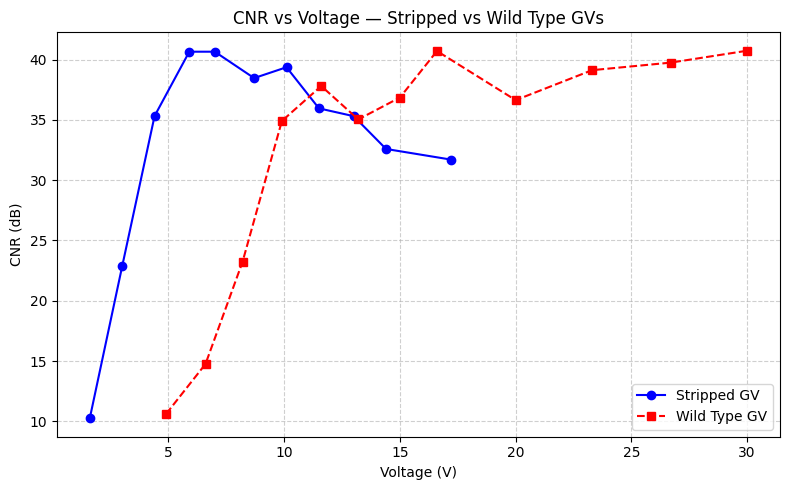

In [36]:
print(f"Stripped GV CNR List: {stripped_gv_cnr_list}")
print(f"Wild Type GV CNR List: {wild_type_gv_cnr_list}")

# Compare Stripped vs Wild Type CNR curves
stripped_v, stripped_cnr = zip(*stripped_gv_cnr_list)
wt_v,       wt_cnr       = zip(*wild_type_gv_cnr_list)

plt.figure(figsize=(8, 5))
plt.plot(stripped_v, stripped_cnr,
         marker='o', linestyle='-',  color='blue', label='Stripped GV')
plt.plot(wt_v, wt_cnr,
         marker='s', linestyle='--', color='red',  label='Wild Type GV')

plt.xlabel('Voltage (V)')
plt.ylabel('CNR (dB)')
plt.title('CNR vs Voltage — Stripped vs Wild Type GVs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Hydrostatic Collapse Pressure

In [6]:
import pandas as pd

# Provide the file path (adjust if needed)
file_path = "./data_excel/06052026_Jt_stripped_3_06052026.xlsx"

# Read all sheets into a dictionary of DataFrames
sheets_dict = pd.read_excel(file_path, sheet_name=None, header=0)

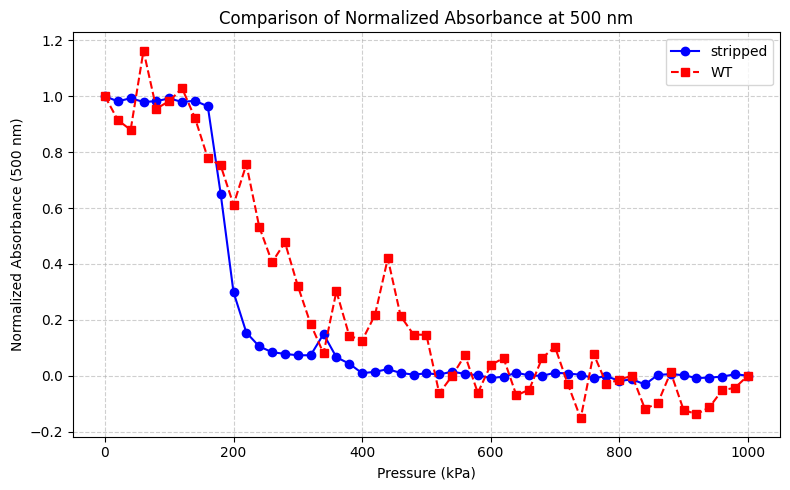

In [45]:
# Compare Stripped and Wild Type curves

# File path
file1 = "./data_excel/06052026_Jt_stripped_3_06052026.xlsx"
file2 = "./data_excel/06052026_Tudor_WT_5_06052026.xlsx"

# Read the "Normalized Abs 500" sheet from each file
df1 = pd.read_excel(file1, sheet_name="Normalized Abs 500")
df2 = pd.read_excel(file2, sheet_name="Normalized Abs 500")

# Plot both curves
plt.figure(figsize=(8, 5))
plt.plot(df1["Pressure (kPa)"], df1["Absorbance 500nm"], 
         marker='o', linestyle='-', color='blue', label="stripped")
plt.plot(df2["Pressure (kPa)"], df2["Absorbance 500nm"], 
         marker='s', linestyle='--', color='red', label="WT")

plt.xlabel("Pressure (kPa)")
plt.ylabel("Normalized Absorbance (500 nm)")
plt.title("Comparison of Normalized Absorbance at 500 nm")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Find Collapse Pressure

Steepest slope (min derivative) = -0.0051
Collapse pressure = 660.00 kPa


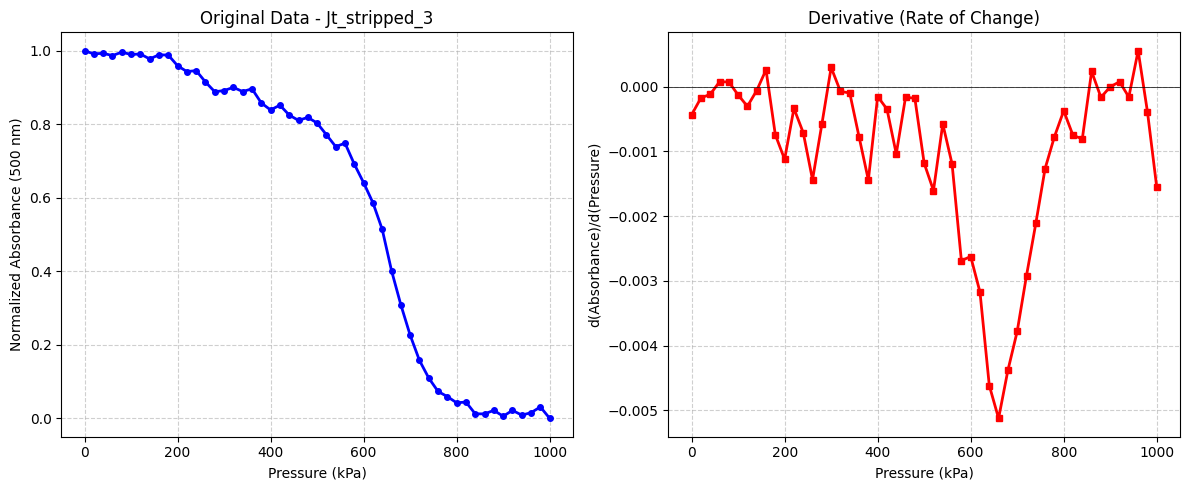

In [43]:
## Find collapse pressure for one case

# File path
file1 = "./data_excel/13052026_Tudor_WT_2_1_13052026.xlsx"

# Read the "Normalized Abs 500" sheet
df1 = pd.read_excel(file1, sheet_name="Normalized Abs 500")

# Extract data
pressure = df1["Pressure (kPa)"].values
absorbance = df1["Absorbance 500nm"].values

# Compute derivative (dy/dx)
# Method 1: Simple finite difference
derivative = np.gradient(absorbance, pressure)
# PLOT original data and derivative

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot original data
ax1.plot(pressure, absorbance, marker='o', linestyle='-', color='blue', linewidth=2, markersize=4)
ax1.set_xlabel("Pressure (kPa)")
ax1.set_ylabel("Normalized Absorbance (500 nm)")
ax1.set_title("Original Data - Jt_stripped_3")
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot derivative
ax2.plot(pressure, derivative, marker='s', linestyle='-', color='red', linewidth=2, markersize=4)
ax2.set_xlabel("Pressure (kPa)")
ax2.set_ylabel("d(Absorbance)/d(Pressure)")
ax2.set_title("Derivative (Rate of Change)")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)  # Zero line

# Pressure at the steepest slope of absorbance (most negative derivative)
min_idx = np.argmin(derivative)
collapse_pressure = pressure[min_idx]

print(f"Steepest slope (min derivative) = {derivative[min_idx]:.4f}")
print(f"Collapse pressure = {collapse_pressure:.2f} kPa")

plt.tight_layout()
plt.show()

Steepest slope (min derivative) = -0.0166
Collapse pressure = 180.00 kPa


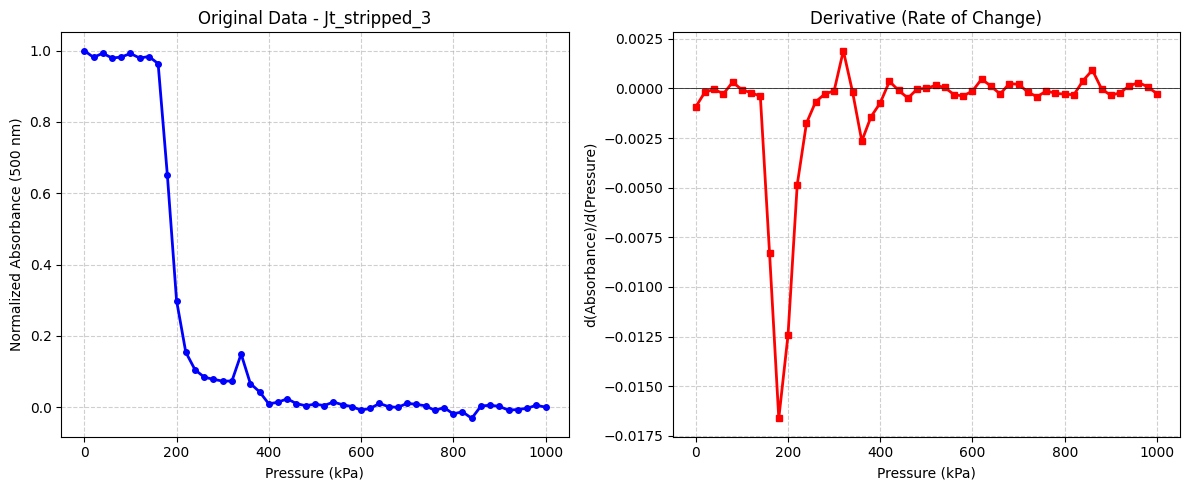

In [44]:
## Find collapse pressure for one case

# File path
file1 = "./data_excel/06052026_Jt_stripped_3_06052026.xlsx"

# Read the "Normalized Abs 500" sheet
df1 = pd.read_excel(file1, sheet_name="Normalized Abs 500")

# Extract data
pressure = df1["Pressure (kPa)"].values
absorbance = df1["Absorbance 500nm"].values

# Compute derivative (dy/dx)
# Method 1: Simple finite difference
derivative = np.gradient(absorbance, pressure)
# PLOT original data and derivative

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot original data
ax1.plot(pressure, absorbance, marker='o', linestyle='-', color='blue', linewidth=2, markersize=4)
ax1.set_xlabel("Pressure (kPa)")
ax1.set_ylabel("Normalized Absorbance (500 nm)")
ax1.set_title("Original Data - Jt_stripped_3")
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot derivative
ax2.plot(pressure, derivative, marker='s', linestyle='-', color='red', linewidth=2, markersize=4)
ax2.set_xlabel("Pressure (kPa)")
ax2.set_ylabel("d(Absorbance)/d(Pressure)")
ax2.set_title("Derivative (Rate of Change)")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)  # Zero line

# Pressure at the steepest slope of absorbance (most negative derivative)
min_idx = np.argmin(derivative)
collapse_pressure = pressure[min_idx]

print(f"Steepest slope (min derivative) = {derivative[min_idx]:.4f}")
print(f"Collapse pressure = {collapse_pressure:.2f} kPa")

plt.tight_layout()
plt.show()